In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [33]:
eda_path = Path.cwd()
base_path = eda_path.parent
data_path = base_path / 'data_preparation' / 'data'
clean_data_path = data_path / 'clean'
clean_data_file = clean_data_path / 'clean_data_trimmed.xlsx'

In [34]:
CLEAN_DATA = pd.read_excel(clean_data_file)
CLEAN_DATA

,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_Высота,lead_FORMNAME,lead_Скидка,lead_Модель телефона,lead_будущие покупки,lead_Квалификация лида,lead_Категория и варианты выбора,lead_Дата создания сделки,lead_Дата перехода в Сборку,lead_Дата перехода Передан в доставку
0,LEAD_0172,2025-03-01 05:35:06,2025-03-01,1,False,2025-03-07 09:11:37,2025-03-12 12:19:04,2025-03-12 12:20:05,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
1,LEAD_0176,2025-03-01 05:51:04,2025-03-01,1,False,2025-03-07 09:09:52,2025-03-10 12:13:09,2025-03-10 15:23:08,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
2,LEAD_0177,2025-03-01 05:54:05,2025-03-01,1,False,2025-03-06 09:32:46,2025-03-19 03:23:15,2025-03-19 06:32:04,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
3,LEAD_0182,2025-03-01 06:18:06,2025-03-01,1,False,2025-03-05 10:11:51,2025-03-09 10:21:31,2025-03-10 15:23:20,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
4,LEAD_0180,2025-03-01 06:42:07,2025-03-01,1,False,2025-03-06 09:31:10,2025-03-09 06:57:12,2025-03-09 10:22:15,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,LEAD_18744,2026-03-27 15:06:15,2026-03-27,0,False,NaT,NaT,NaT,NaT,NaT,...,NaN,consult,NaN,Смартфон,не известно,А - лид,D,2026-03-26 21:00:00,2026-03-26 21:00:00,NaT
17962,LEAD_18782,2026-03-28 07:21:07,2026-03-28,0,False,NaT,NaT,NaT,NaT,NaT,...,NaN,consult,NaN,Смартфон,не известно,А - лид,D,2026-03-27 21:00:00,2026-03-27 21:00:00,NaT
17963,LEAD_18784,2026-03-28 07:32:08,2026-03-28,0,False,NaT,NaT,NaT,NaT,NaT,...,NaN,consult,10.0,Не удалось узнать,не известно,А - лид,S,2026-03-27 21:00:00,2026-03-27 21:00:00,NaT
17964,LEAD_18794,2026-03-28 10:35:07,2026-03-28,0,False,NaT,NaT,NaT,NaT,NaT,...,NaN,NaN,NaN,Не удалось узнать,не известно,А - лид,S,2026-03-27 21:00:00,2026-03-27 21:00:00,NaT


In [35]:
CLEAN_DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 72 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   lead_id                                17966 non-null  object        
 1   sale_ts                                17966 non-null  datetime64[ns]
 2   sale_date                              17966 non-null  datetime64[ns]
 3   buyout_flag                            17966 non-null  int64         
 4   outcome_unknown                        17966 non-null  bool          
 5   handed_to_delivery_ts                  17541 non-null  datetime64[ns]
 6   issued_or_pvz_ts                       17206 non-null  datetime64[ns]
 7   received_ts                            14882 non-null  datetime64[ns]
 8   rejected_ts                            2630 non-null   datetime64[ns]
 9   returned_ts                            2533 non-null   dateti

**Интернет-страницы о метриках взаимосвязей признаков:**
* ?Дмитрий Макаров: https://www.dmitrymakarov.ru/learning/relationship/
* ?Habr: https://habr.com/ru/companies/gazprombank/articles/881386/

In [70]:
CLEAN_DATA_real = CLEAN_DATA.select_dtypes(['int64', 'float64'])
CLEAN_DATA_categorical = CLEAN_DATA.select_dtypes(['object', 'bool'])
CLEAN_DATA_time = CLEAN_DATA.select_dtypes(['datetime64[ns]'])
#CLEAN_DATA_real

In [59]:
all_corr = CLEAN_DATA_real.corr()

In [68]:
def CategoricalUniform(DATA):
    CUdData = {}
    for label in DATA.columns.tolist():
        column = DATA[label]
        unique = pd.unique(column).tolist()
        transformDict = {i: j for i, j in zip(unique, range(len(unique)))}
        CUdData[label] = column.apply(lambda x: transformDict[x])
    return pd.DataFrame(CUdData)

In [69]:
CategoricalUniform(CLEAN_DATA.select_dtypes(['object']))

,lead_id,lead_responsible_user_id,lead_tags,lead_utm_source,lead_utm_medium,lead_utm_campaign,lead_utm_content,lead_utm_term,lead_utm_group,lead_utm_sky,...,contact_Трекинг,lead_Условный отказ,lead_Трек-номер,lead_Трек-номер СДЭК,lead_Тариф Доставки,lead_FORMNAME,lead_Модель телефона,lead_будущие покупки,lead_Квалификация лида,lead_Категория и варианты выбора
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,2,0,0,2,2,2,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,1,3,1,1,3,3,3,1,1,...,0,0,0,0,0,0,0,0,0,0
4,4,0,4,0,0,4,4,1,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,17961,11,1026,16,0,967,10843,123,13,0,...,0,0,0,0,2,3,2,1,1,2
17962,17962,18,1026,16,0,1041,10844,123,13,0,...,0,0,0,0,3,3,2,1,1,2
17963,17963,17,1026,16,0,1070,10845,123,13,0,...,0,0,0,0,1,3,3,1,1,5
17964,17964,22,1109,1,1,3,3,3,1,1,...,0,0,0,0,3,0,3,1,1,5


In [86]:
from scipy.stats import chi2_contingency
from tqdm import tqdm
def cramers_v(confusion_matrix):
    print(confusion_matrix.shape)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    v = np.sqrt(chi2 / (n * min_dim))
    return v
def cramers_v_matrix_optimized(DATA):
    categorical_columns = DATA.columns.tolist()
    
    n_cols = len(categorical_columns)
    v_matrix = np.eye(n_cols)
    unique_values = {col: DATA[col].fillna('MISSING').astype(str) for col in categorical_columns}
    
    for i in tqdm(range(n_cols)):
        for j in range(i + 1, n_cols):
            col1, col2 = categorical_columns[i], categorical_columns[j]
            
            # Создаем таблицу сопряженности
            contingency = pd.crosstab(unique_values[col1], unique_values[col2])
            v_value = cramers_v(contingency.values)
            
            v_matrix[i, j] = v_value
            v_matrix[j, i] = v_value
    
    return pd.DataFrame(v_matrix, index=categorical_columns, columns=categorical_columns)

In [94]:
'''cimport cython
from cython cimport Py_ssize_t
from libc.math cimport (
    isnan,
    sqrt,
)
from libc.stdlib cimport (
    free,
    malloc,
)
from libc.string cimport memcpy

import numpy as np

cimport numpy as cnp
from numpy cimport (
    NPY_FLOAT64,
    NPY_INT8,
    NPY_INT16,
    NPY_INT32,
    NPY_INT64,
    NPY_OBJECT,
    NPY_UINT64,
    float32_t,
    float64_t,
    int8_t,
    int16_t,
    int32_t,
    int64_t,
    intp_t,
    ndarray,
    uint8_t,
    uint16_t,
    uint32_t,
    uint64_t,
)

cnp.import_array()

cimport pandas._libs.util as util
from pandas._libs.dtypes cimport (
    numeric_object_t,
    numeric_t,
)
from pandas._libs.khash cimport (
    kh_destroy_int64,
    kh_get_int64,
    kh_init_int64,
    kh_int64_t,
    kh_put_int64,
    kh_resize_int64,
    khiter_t,
)
from pandas._libs.missing cimport (
    checknull,
    isnaobj,
)
from pandas._libs.util cimport get_nat

cdef:
    float64_t FP_ERR = 1e-13
    float64_t NaN = <float64_t>np.nan
    int64_t NPY_NAT = get_nat()


tiebreakers = {
    "average": TIEBREAK_AVERAGE,
    "min": TIEBREAK_MIN,
    "max": TIEBREAK_MAX,
    "first": TIEBREAK_FIRST,
    "dense": TIEBREAK_DENSE,
}'''

SyntaxError: invalid syntax (2144215408.py, line 1)

In [ ]:
'''@cython.boundscheck(False)
@cython.wraparound(False)
@cython.cdivision(True)
def nancorr_CramersV(const float64_t[:, :] mat, bint cov=False, minp=None):
    cdef:
        Py_ssize_t i, xi, yi, N, K
        int64_t minpv
        float64_t[:, ::1] result
        uint8_t[:, :] mask
        int64_t nobs = 0
        float64_t vx, vy, dx, dy, meanx, meany, divisor, ssqdmx, ssqdmy, covxy, val

    N, K = (<object>mat).shape
    if minp is None:
        minpv = 1
    else:
        minpv = <int64_t>minp

    result = np.empty((K, K), dtype=np.float64)
    mask = np.isfinite(mat).view(np.uint8)

    with nogil:
        for xi in range(K):
            for yi in range(xi + 1):
                # Welford's method for the variance-calculation
                # https://en.wikipedia.org/wiki/Algorithms_for_calculating_variance
                nobs = ssqdmx = ssqdmy = covxy = meanx = meany = 0
                for i in range(N):
                    if mask[i, xi] and mask[i, yi]:
                        vx = mat[i, xi]
                        vy = mat[i, yi]
                        nobs += 1
                        dx = vx - meanx
                        dy = vy - meany
                        meanx += 1. / nobs * dx
                        meany += 1. / nobs * dy
                        ssqdmx += (vx - meanx) * dx
                        ssqdmy += (vy - meany) * dy
                        covxy += (vx - meanx) * dy

                if nobs < minpv:
                    result[xi, yi] = result[yi, xi] = NaN
                else:
                    divisor = (nobs - 1.0) if cov else sqrt(ssqdmx * ssqdmy)

                    # clip `covxy / divisor` to ensure coeff is within bounds
                    if divisor != 0:
                        val = covxy / divisor
                        if not cov:
                            if val > 1.0:
                                val = 1.0
                            elif val < -1.0:
                                val = -1.0
                        result[xi, yi] = result[yi, xi] = val
                    else:
                        result[xi, yi] = result[yi, xi] = NaN

    return result.base'''

In [95]:
!pip install phik


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/675.0 kB ? eta -:--:--
   ------------------------------- -------- 524.3/675.0 kB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 675.0/675.0 kB 2.4 MB/s eta 0:00:00


In [111]:
#Добавить F-value, p-value, Phik-value, коэффициент Стьюдента, коэффициент Фишера
CheddockClasses = ['Нет корреляции', 'Слабая корреляция', 'Умеренная корреляция', 'Заметная корреляция', 'Тесная корреляция', 'Очень тесная корреляция', 'Функциональная корреляция']
CramersVClasses = ['Слабая корреляция', 'Умеренная корреляция', 'Сильная корреляция']
PhiKClasses = ['Слабая корреляция', 'Умеренная корреляция', 'Заметная корреляция', 'Высокая корреляция', 'Очень высокая корреляция']
def SeriesClassification(x, func, *args):
    return x.apply(func, args = args)
def CheddockClassification(x, classtype = 'label'):
    global CheddockClasses
    classes = CheddockClasses
    ax = abs(x)
    Class = 6
    if ax<0.1:
        Class = 0
    elif (0.1<=ax<0.3):
        Class = 1
    elif (0.3<=ax<0.5):
        Class = 2
    elif (0.5<=ax<0.7):
        Class = 3
    elif (0.7<=ax<0.9):
        Class = 4
    elif (0.9<=ax<1):
        Class = 5
    if classtype == 'label':
        return classes[Class]
    return Class
def CramersVClassification(x, classtype = 'label'):
    global CramersVClasses
    classes = CramersVClasses
    Class = 2
    if x<=0.2:
        Class = 0
    elif (0.2<x<=0.6):
        Class = 1
    if classtype == 'label':
        return classes[Class]
    return Class
def pvalueClassification(x, classtype = 'label', importance_level = 0.05):
    classes = ['Есть статистически значимые различия', 'Нет статистически значимых различий']
    Class = 1
    if x<importance_level:
        Class = 0
    if classtype == 'label':
        return classes[Class]
    return Class
def PhiKClassification(x, classtype = 'label'):
    global PhiKClasses
    classes = PhiKClasses
    Class = 4
    if x<=0.2:
        Class = 0
    elif (0.2<x<=0.4):
        Class = 1
    elif (0.4<x<=0.6):
        Class = 2
    elif (0.6<x<=0.8):
        Class = 3
    if classtype == 'label':
        return classes[Class]
    return Class
def FindCorrelations(DATA, corr_types = ['pierson', 'spearman', 'kendall', 'Cramer\'s V', 'PhiK']):
    Corrs = {}
    DATA_real = DATA.select_dtypes(['int64', 'float64'])
    DATA_categorical = DATA.select_dtypes(['object', 'bool'])
    DATA_categorical['buyout_flag'] = DATA['buyout_flag']
    DATA_time = DATA.select_dtypes(['datetime64[ns]'])
    if 'pierson' in corr_types:
        Corrs['pierson'] = DATA_real.corr()
        Corrs['pierson_classes'] = Corrs['pierson'].apply(SeriesClassification, args = (CheddockClassification, 0, ))
        Corrs['pierson_labeledClasses'] = Corrs['pierson'].apply(SeriesClassification, args = (CheddockClassification, ))
    if 'spearman' in corr_types:
        Corrs['spearman'] = DATA_real.corr(method = 'spearman')
        Corrs['spearman_classes'] = Corrs['spearman'].apply(SeriesClassification, args = (CheddockClassification, 0, ))
        Corrs['spearman_labeledClasses'] = Corrs['spearman'].apply(SeriesClassification, args = (CheddockClassification, ))
    if 'kendall' in corr_types:
        Corrs['kendall'] = DATA_real.corr(method = 'kendall')
        Corrs['kendall_classes'] = Corrs['kendall'].apply(SeriesClassification, args = (CheddockClassification, 0, ))
        Corrs['kendall_labeledClasses'] = Corrs['kendall'].apply(SeriesClassification, args = (CheddockClassification, ))
    if 'Cramer\'s V' in corr_types:
        '''Corrs['Cramer\'s V'] = cramers_v_matrix_optimized(DATA_categorical)
        Corrs['Cramer\'s V_classes'] = Corrs['Cramer\'s V'].apply(SeriesClassification, args = (CramersVClassification, 0, ))
        Corrs['Cramer\'s V_labeledClasses'] = Corrs['Cramer\'s V'].apply(SeriesClassification, args = (CheddockClassification, ))'''
    if 'PhiK' in corr_types:
        import phik
        from phik import resources, report
        Corrs['PhiK'] = DATA.select_dtypes(['int64', 'float64', 'object']).phik_matrix()
        Corrs['PhiK_classes'] = Corrs['PhiK'].apply(SeriesClassification, args = (PhiKClassification, 0, ))
        Corrs['PhiK_labeledClasses'] = Corrs['PhiK'].apply(SeriesClassification, args = (PhiKClassification, ))
    return Corrs
def buyoutCorrelations(Corrs):
    return pd.DataFrame({i: j['buyout_flag'] for i, j in Corrs.items()})

In [138]:
corr_types = ['pierson', 'spearman', 'kendall']
Corrs = FindCorrelations(CLEAN_DATA, ['pierson', 'spearman', 'kendall'])

In [101]:
buyout_corr = buyoutCorrelations(Corrs)

In [79]:
buyout_corr

,pierson,pierson_classes,pierson_labeledClasses,spearman,spearman_classes,spearman_labeledClasses,kendall,kendall_classes,kendall_labeledClasses,Cramer's V,Cramer's V_classes,Cramer's V_labeledClasses
buyout_flag,1.000000,6,Функциональная корреляция,1.000000,6,Функциональная корреляция,1.000000,6,Функциональная корреляция,1.0,2.0,Сильная корреляция
contact_LTV,0.008746,0,Нет корреляции,-0.000736,0,Нет корреляции,-0.000601,0,Нет корреляции,NaN,NaN,NaN
contact_Число сделок,0.008421,0,Нет корреляции,-0.005833,0,Нет корреляции,-0.005577,0,Нет корреляции,NaN,NaN,NaN
days_handed_to_issued_pvz,-0.107885,1,Слабая корреляция,-0.090365,0,Нет корреляции,-0.073869,0,Нет корреляции,NaN,NaN,NaN
days_sale_to_handed,-0.008880,0,Нет корреляции,-0.009328,0,Нет корреляции,-0.007636,0,Нет корреляции,NaN,NaN,NaN
days_to_outcome,-0.701272,4,Тесная корреляция,-0.492031,2,Умеренная корреляция,-0.401915,2,Умеренная корреляция,NaN,NaN,NaN
lead_group_id,-0.033984,0,Нет корреляции,-0.027601,0,Нет корреляции,-0.025244,0,Нет корреляции,NaN,NaN,NaN
lead_pipeline_id,0.002091,0,Нет корреляции,-0.116995,1,Слабая корреляция,-0.116845,1,Слабая корреляция,NaN,NaN,NaN
lead_price,-0.004619,0,Нет корреляции,-0.048127,0,Нет корреляции,-0.039311,0,Нет корреляции,NaN,NaN,NaN
lead_status_id,-0.273926,1,Слабая корреляция,-0.859179,4,Тесная корреляция,-0.835690,4,Тесная корреляция,NaN,NaN,NaN


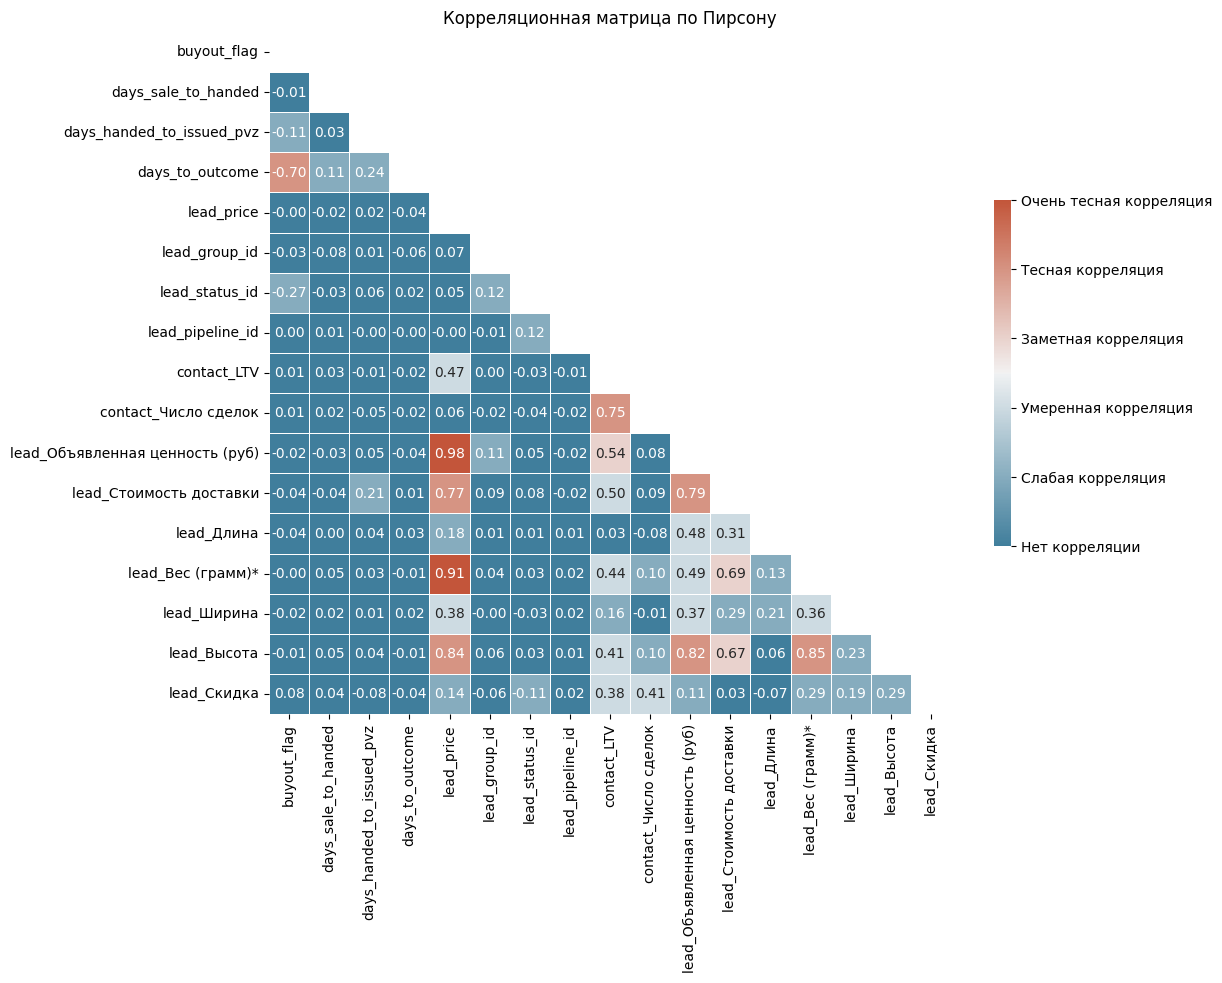

In [141]:
mask = np.triu(np.ones_like(Corrs['pierson_classes'], dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

cax = sns.heatmap(Corrs['pierson_classes'], mask=mask, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs['pierson'], fmt = '.2f')
cax.set_title('Корреляционная матрица по Пирсону')
cbar = cax.collections[0].colorbar
cbar.set_ticks(ticks=[i for i in range(len(CheddockClasses[:-1]))], labels=CheddockClasses[:-1])

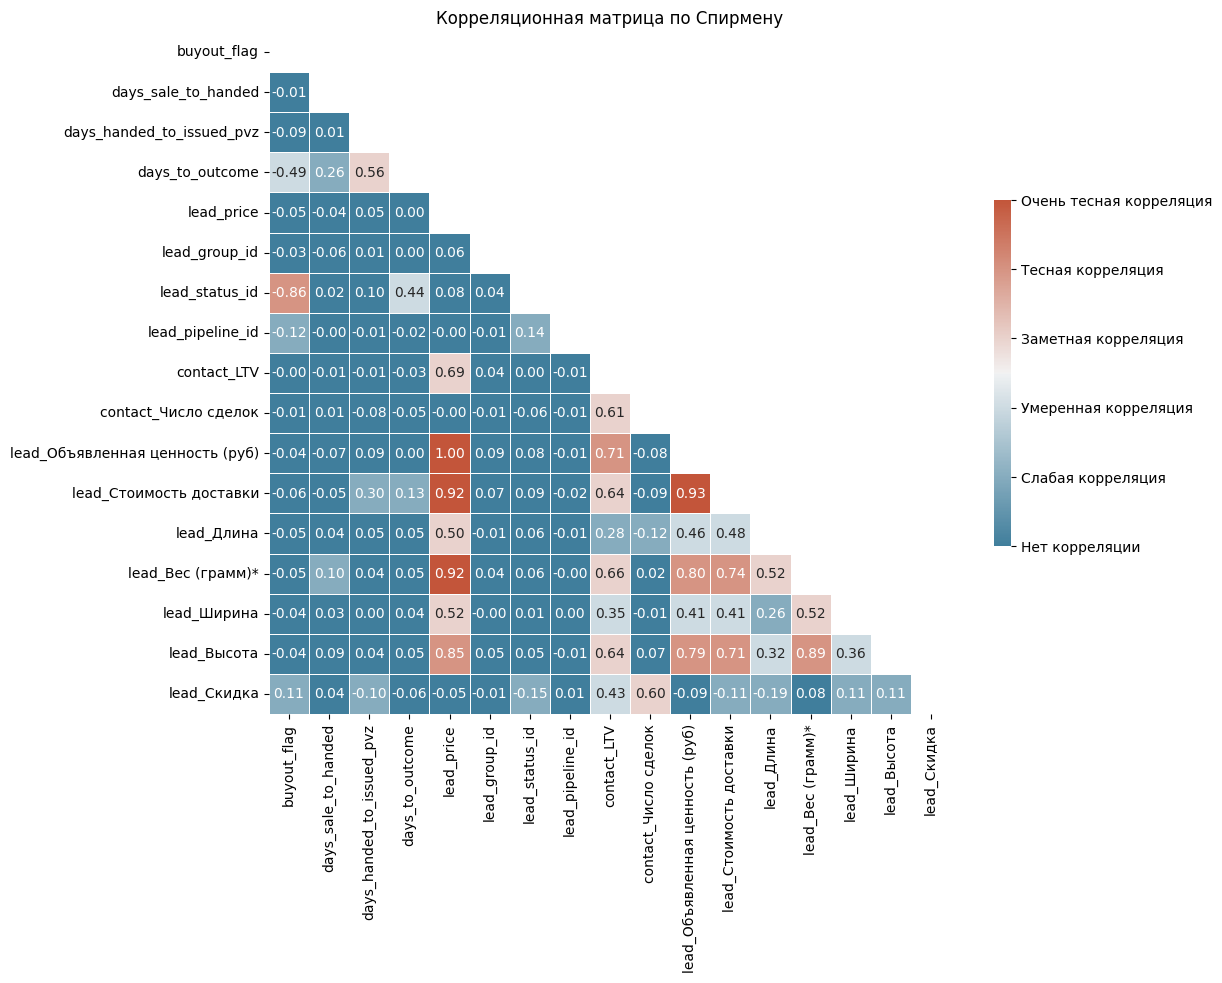

In [140]:
mask = np.triu(np.ones_like(Corrs['spearman_classes'], dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

cax = sns.heatmap(Corrs['spearman_classes'], mask=mask, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs['spearman'], fmt = '.2f')
cax.set_title('Корреляционная матрица по Спирмену')
cbar = cax.collections[0].colorbar
cbar.set_ticks(ticks=[i for i in range(len(CheddockClasses[:-1]))], labels=CheddockClasses[:-1])

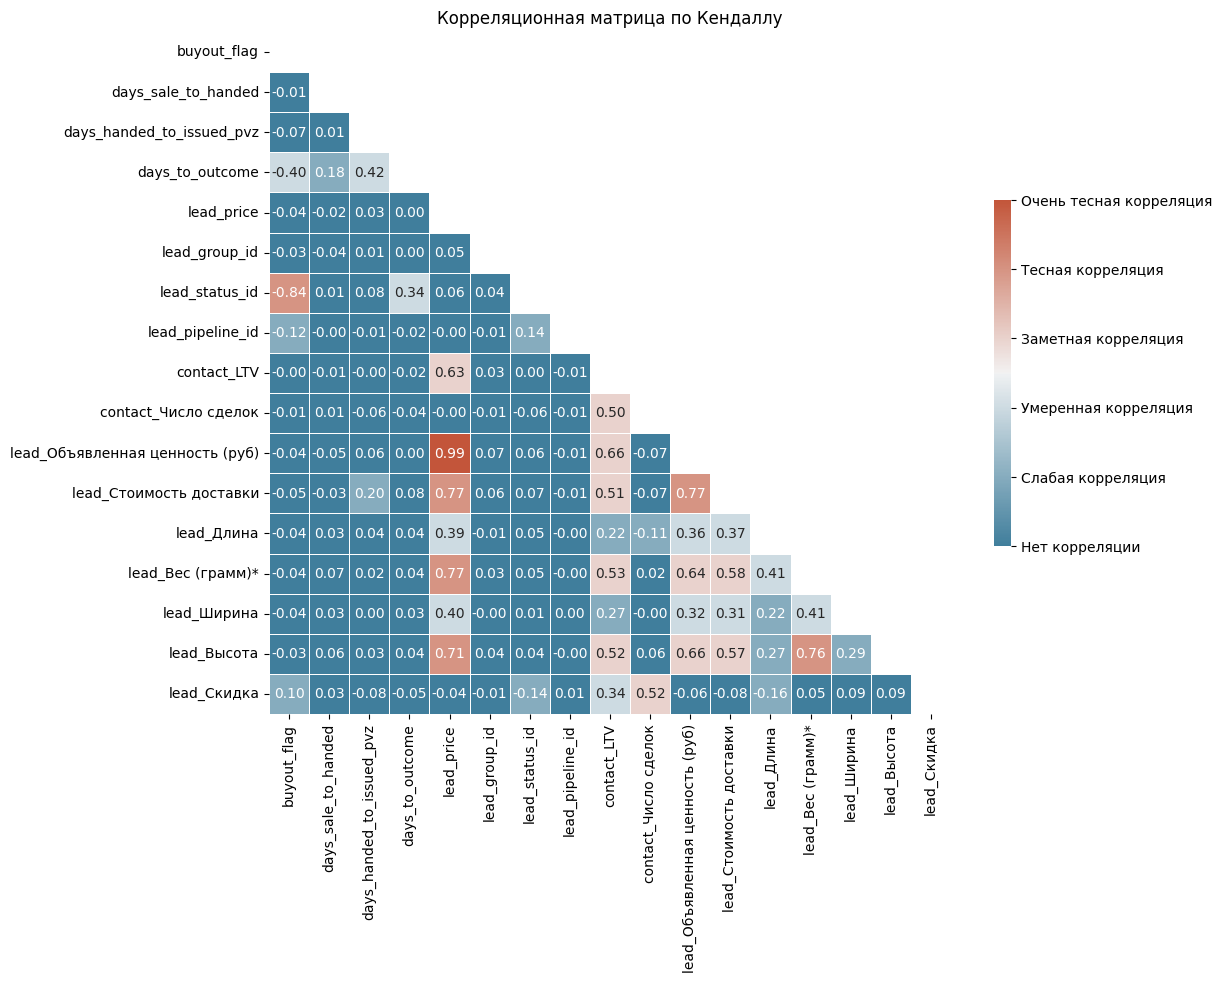

In [139]:
mask = np.triu(np.ones_like(Corrs['kendall_classes'], dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

cax = sns.heatmap(Corrs['kendall_classes'], mask=mask, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs['kendall'], fmt = '.2f')
cax.set_title('Корреляционная матрица по Кендаллу')
cbar = cax.collections[0].colorbar
cbar.set_ticks(ticks=[i for i in range(len(CheddockClasses[:-1]))], labels=CheddockClasses[:-1])

In [144]:
def VisualizeCorrMatrix(Corrs, corr_type):
    mask = np.triu(np.ones_like(Corrs[corr_type+'_classes'], dtype=bool))

    f, ax = plt.subplots(figsize=(11, 9))

    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    title = 'Корреляционная матрица по '
    classes = []
    global CheddockClasses
    global CramersVClasses
    global PhiKClasses
    if corr_type == 'pierson':
        classes = CheddockClasses[:-1]
        title+='Пирсону'
    elif corr_type == 'spearman':
        classes = CheddockClasses[:-1]
        title+='Спирмену'
    elif corr_type == 'kendall':
        classes = CheddockClasses[:-1]
        title+='Кендаллу'
    elif corr_type == 'Cramer\'s V':
        classes = CramersVClasses
        title+='Крамеру-В'
    elif corr_type == 'PhiK':
        classes = PhiKClasses
        title+='Ф-К'
    cax = sns.heatmap(Corrs[corr_type+'_classes'], mask=mask, cmap=cmap,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs[corr_type], fmt = '.2f')
    cax.set_title(title)
    cbar = cax.collections[0].colorbar
    cbar.set_ticks(ticks=[i for i in range(len(classes))], labels=classes)
    plt.show()

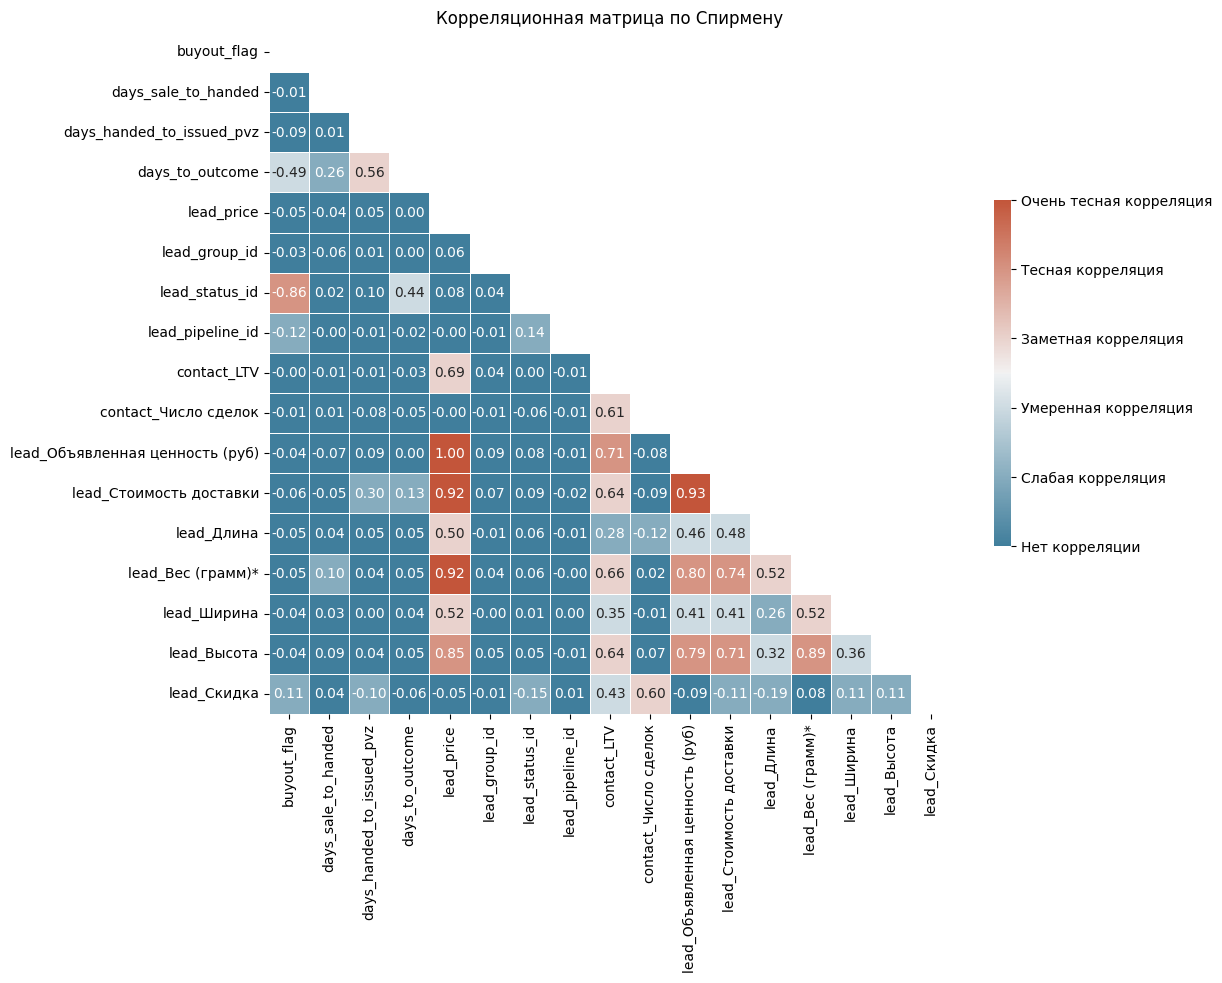

In [145]:
VisualizeCorrMatrix(Corrs, 'spearman')

In [192]:
def dropRareCategories(DATA, numthreshold = 3, percthreshold = 0):
    cols = DATA.columns.tolist()
    UDATA = DATA
    UDATA = UDATA.groupby(cols[0]).sum().sort_values(cols[1], ascending = False).iloc[:numthreshold]
    AVGDATA = UDATA/UDATA.sum()*100
    UDATA = UDATA[AVGDATA>percthreshold]
    return UDATA

C:\Users\andra\AppData\Local\Temp\ipykernel_25344\344913717.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


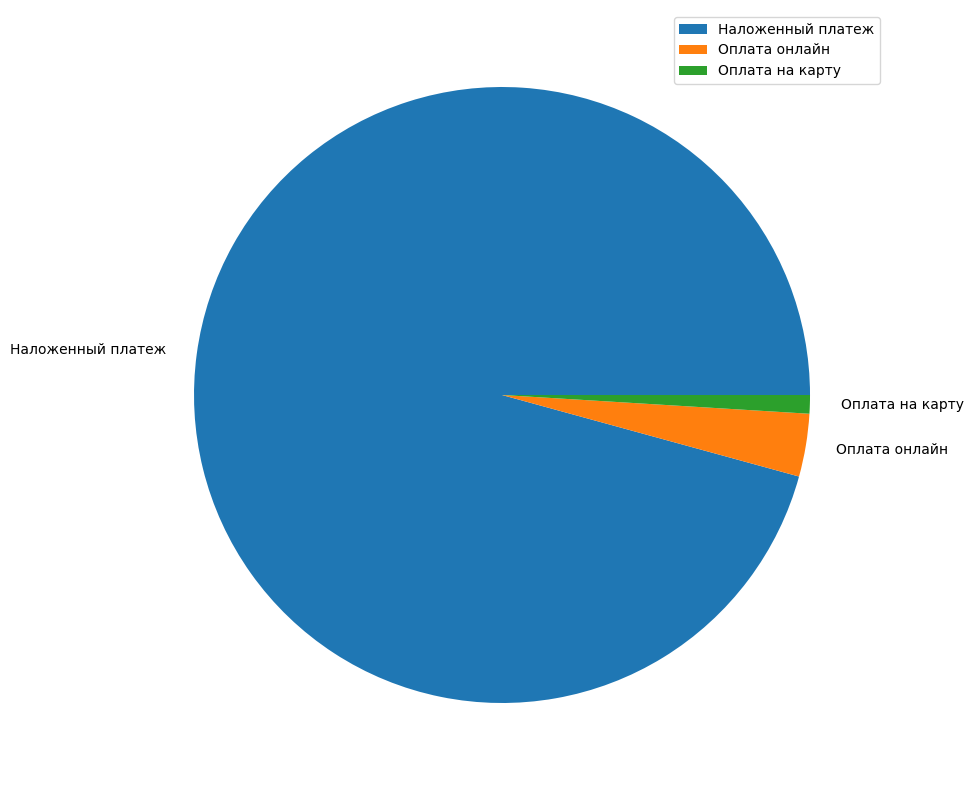

In [219]:
Pie = CLEAN_DATA[['lead_Вид оплаты']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.1)
ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
ax.legend(loc = 1)

C:\Users\andra\AppData\Local\Temp\ipykernel_25344\1328794988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


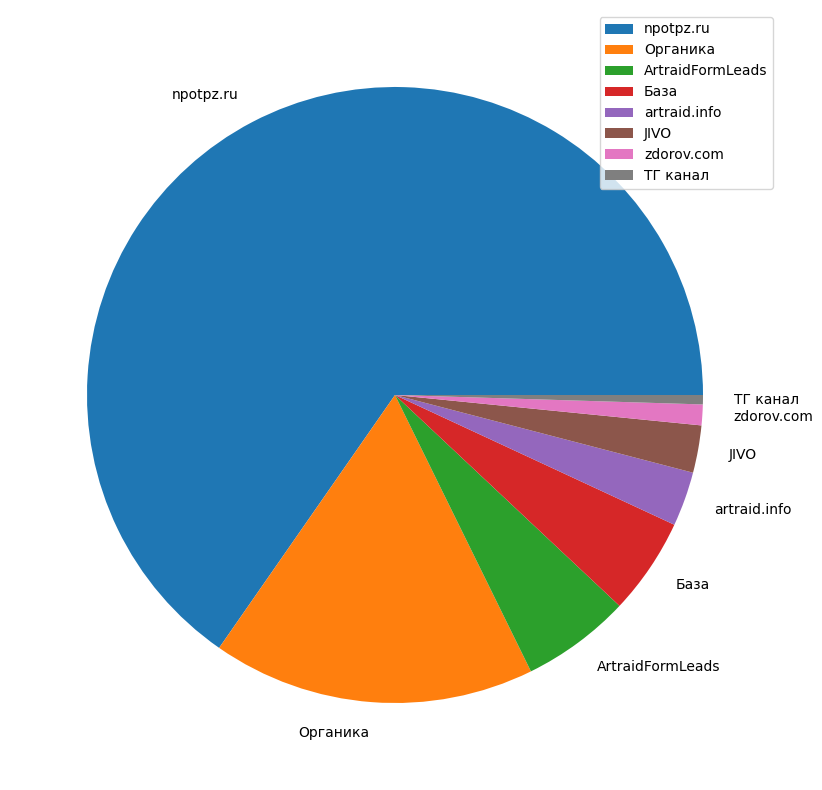

In [218]:
Pie = CLEAN_DATA[['lead_Источник']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0)
ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
ax.legend(loc = 1)

C:\Users\andra\AppData\Local\Temp\ipykernel_25344\639134104.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


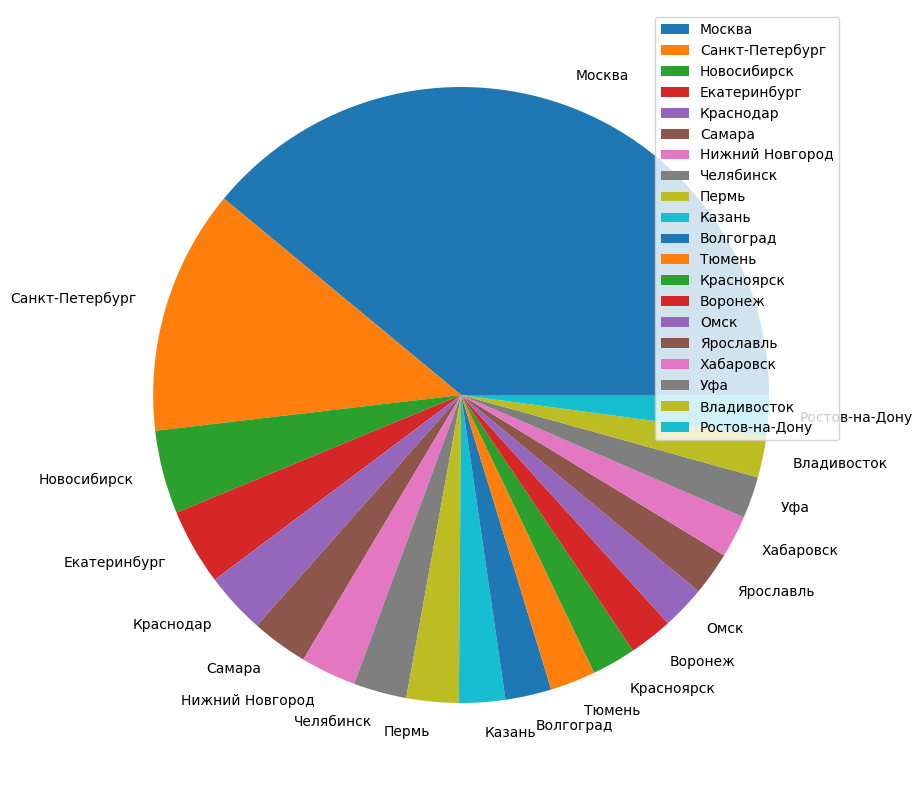

In [217]:
Pie = CLEAN_DATA[['contact_Город']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20)
ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
ax.legend(loc = 1)

C:\Users\andra\AppData\Local\Temp\ipykernel_25344\1793539167.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


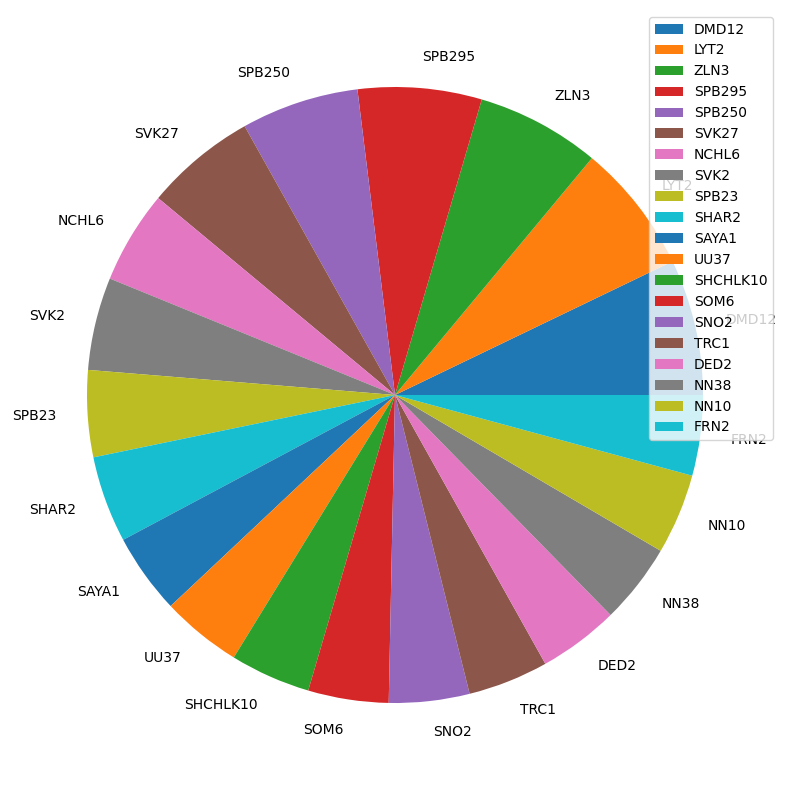

In [216]:
Pie = CLEAN_DATA[['contact_Код ПВЗ']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20)
ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
ax.legend(loc = 1)

C:\Users\andra\AppData\Local\Temp\ipykernel_25344\2825752076.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


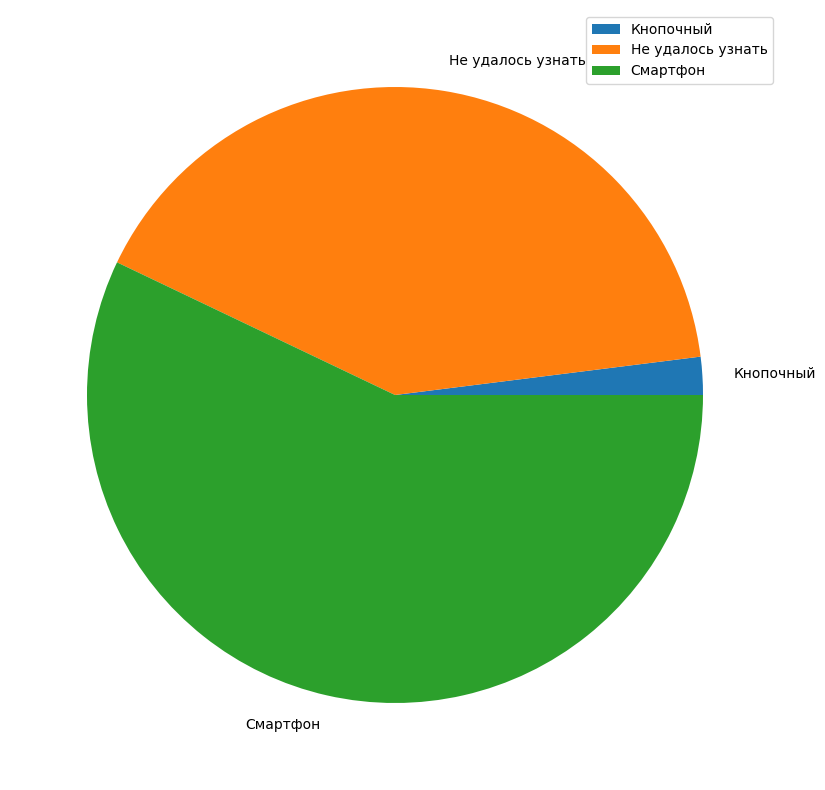

In [215]:
Pie = CLEAN_DATA[['lead_Модель телефона']]
Pie['Количество'] = 1
Pie = Pie.groupby('lead_Модель телефона').sum()
ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
ax.legend(loc = 1)

C:\Users\andra\AppData\Local\Temp\ipykernel_25344\2731147630.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


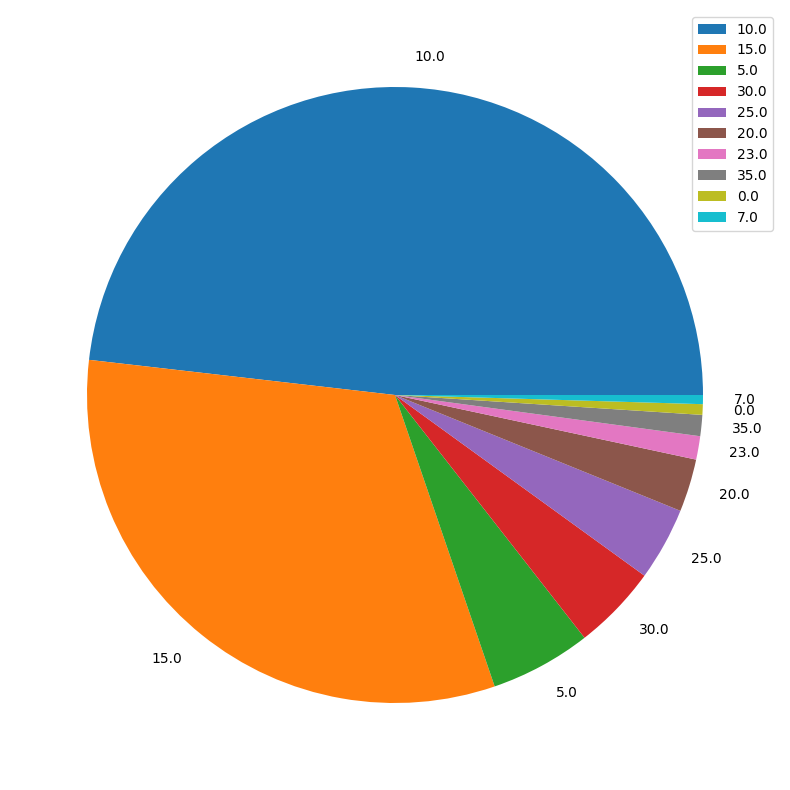

In [214]:
Pie = CLEAN_DATA[['lead_Скидка']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.2)
ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
ax.legend(loc = 1)

C:\Users\andra\AppData\Local\Temp\ipykernel_25344\3153717149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


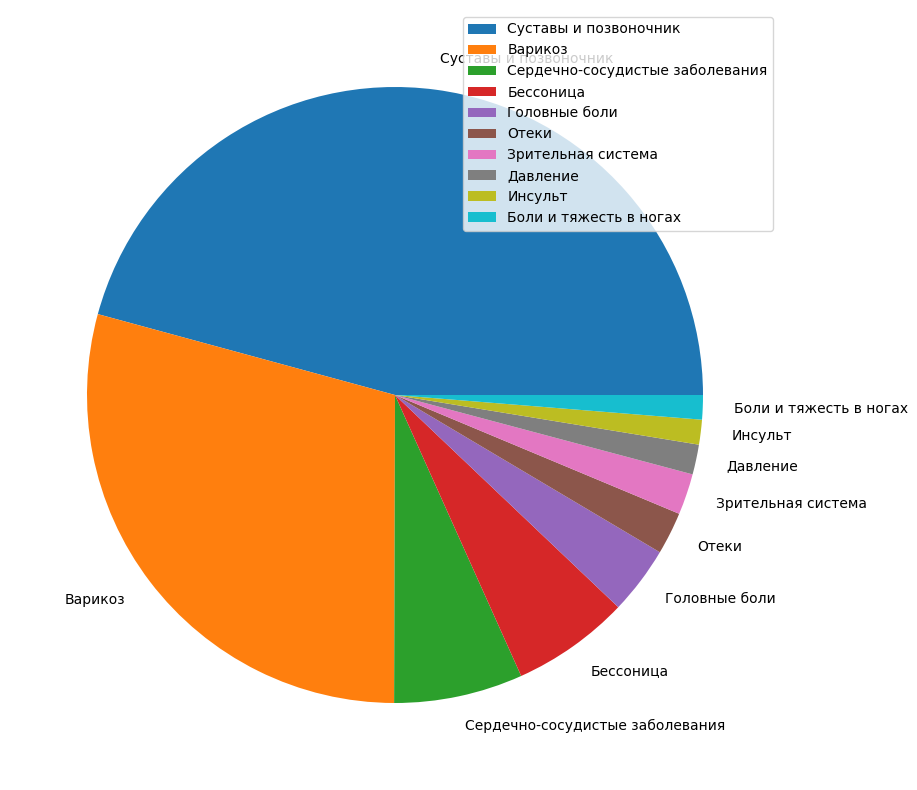

In [213]:
Pie = CLEAN_DATA[['lead_Проблема']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.5)
ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
ax.legend(loc = 1)

<Axes: >

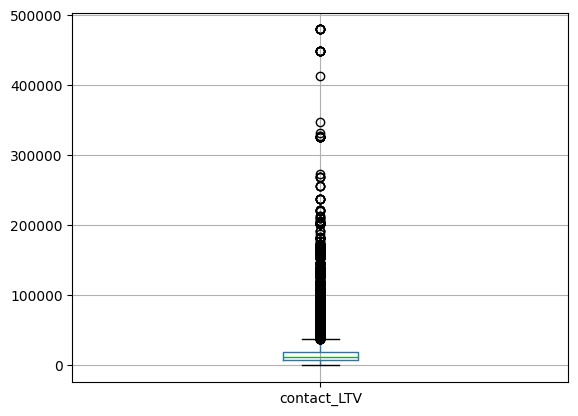

In [209]:
Box = CLEAN_DATA[['contact_LTV']].dropna()
Box.boxplot()

<Axes: >

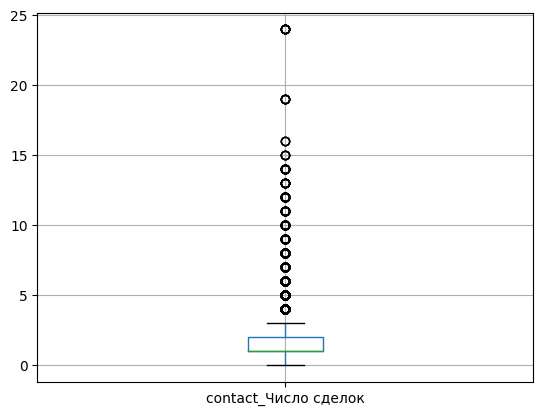

In [210]:
Box = CLEAN_DATA[['contact_Число сделок']].dropna()
Box.boxplot()

<Axes: >

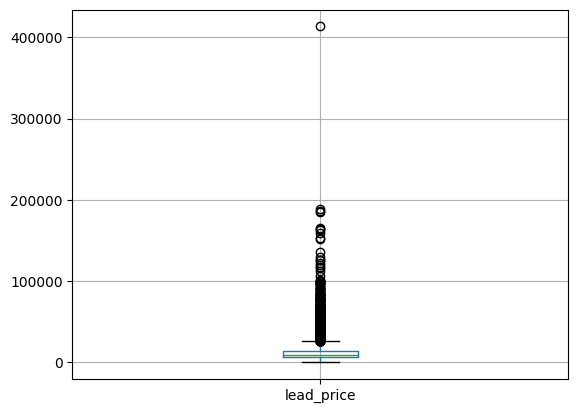

In [211]:
Box = CLEAN_DATA[['lead_price']].dropna()
Box.boxplot()

<Axes: >

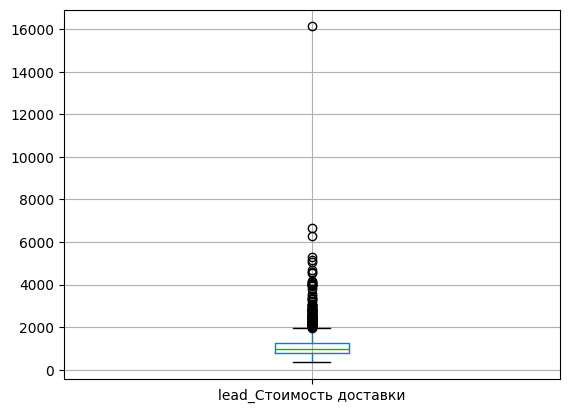

In [212]:
Box = CLEAN_DATA[['lead_Стоимость доставки']].dropna()
Box.boxplot()

<Axes: >

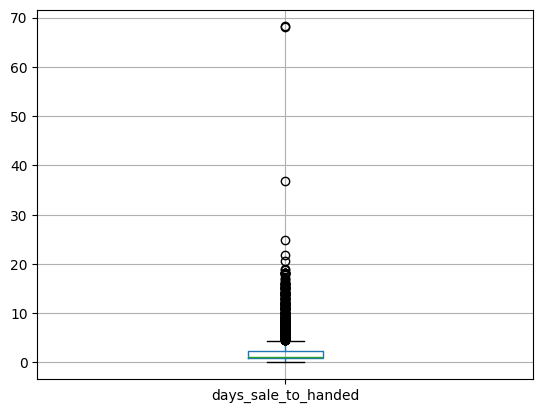

In [221]:
#70?
Box = CLEAN_DATA[['days_sale_to_handed']].dropna()
Box.boxplot()

<Axes: >

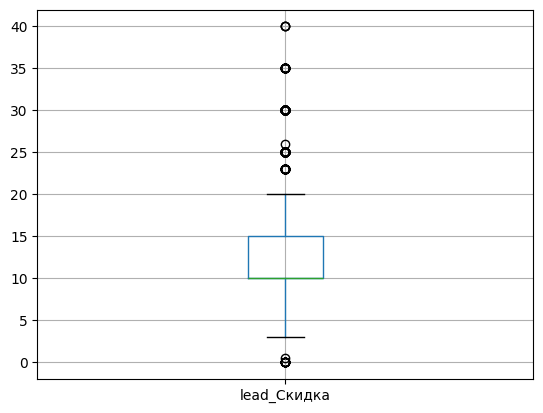

In [222]:
Box = CLEAN_DATA[['lead_Скидка']].dropna()
Box.boxplot()